In [2]:
import pandas as pd
import os

# Create the docs folder if it does not already exist
os.makedirs("docs", exist_ok=True)

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(
        f"docs/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
df = pd.read_csv(
    "../data/cleaned_properties.csv",
    parse_dates=["date_listed", "date_scraped"]
)

print("Shape:", df.shape)
df.head()
df.info()
df[["date_listed", "date_scraped"]].dtypes

# Duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Duplicate IDs
duplicate_ids = df["id"].duplicated().sum()

print("Duplicate IDs:", duplicate_ids)
print("\nProperty types:")
print(df["property_type"].value_counts())

print("\nConditions:")
print(df["condition"].value_counts())
print(df["market_type"].value_counts())

Shape: (170, 20)
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              170 non-null    int64         
 1   title           170 non-null    str           
 2   price           170 non-null    int64         
 3   price_per_m2    170 non-null    float64       
 4   location        170 non-null    str           
 5   district        170 non-null    str           
 6   area            170 non-null    int64         
 7   bedrooms        170 non-null    int64         
 8   property_type   170 non-null    str           
 9   condition       170 non-null    str           
 10  has_parking     170 non-null    bool          
 11  has_garden      170 non-null    bool          
 12  date_listed     170 non-null    datetime64[us]
 13  date_scraped    170 non-null    datetime64[us]
 14  days_listed     170 non-null    int64         
 15  

In [3]:
df[[
    "price",
    "price_per_m2",
    "area",
    "bedrooms",
    "days_listed",
    "quality_score",
    "features_score",
    "value_score"
]].describe()

,price,price_per_m2,area,bedrooms,days_listed,quality_score,features_score,value_score
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,247271.864706,1434.088353,171.488235,2.617647,25.470588,3.347059,0.929412,50.458824
std,217816.127285,709.508875,150.093274,1.305761,22.659605,0.878822,0.611299,28.529048
min,30000.000000,103.540000,40.000000,0.000000,7.000000,2.000000,0.000000,0.000000
25%,95753.250000,812.307500,93.000000,2.000000,10.000000,3.000000,1.000000,27.000000
50%,182574.000000,1301.495000,140.000000,3.000000,16.500000,3.000000,1.000000,50.500000
75%,303237.750000,2002.837500,193.500000,3.000000,31.500000,4.000000,1.000000,75.500000
max,968768.000000,3259.700000,1627.000000,6.000000,96.000000,5.000000,2.000000,99.000000


In [4]:
df["bedrooms"].value_counts().sort_index()
df[df["bedrooms"] == 0][
    ["id", "title", "property_type", "area", "price", "bedrooms"]
]

,id,title,property_type,area,price,bedrooms
119,141,Terrain 1627m² à Jendouba,Land,1627,968768,0
124,151,Terrain 309m² à Nabeul,Land,309,559738,0


In [5]:
total_properties = len(df)

avg_price = df["price"].mean()
median_price = df["price"].median()

avg_price_m2 = df["price_per_m2"].mean()
median_price_m2 = df["price_per_m2"].median()

avg_area = df["area"].mean()
median_area = df["area"].median()

avg_days_listed = df["days_listed"].mean()
median_days_listed = df["days_listed"].median()

print("Total properties:", total_properties)
print("Average price:", round(avg_price, 2))
print("Median price:", round(median_price, 2))
print("Average price per m²:", round(avg_price_m2, 2))
print("Median price per m²:", round(median_price_m2, 2))
print("Average area:", round(avg_area, 2))
print("Median area:", round(median_area, 2))
print("Average days listed:", round(avg_days_listed, 2))
print("Median days listed:", round(median_days_listed, 2))

Total properties: 170
Average price: 247271.86
Median price: 182574.0
Average price per m²: 1434.09
Median price per m²: 1301.49
Average area: 171.49
Median area: 140.0
Average days listed: 25.47
Median days listed: 16.5


Market Overview Insights:

• The dataset contains 170 real-estate listings.
• The median property price is 182,574, while the average is higher at 247,272.
• The median price per m² is 1,301.49.
• The typical property has an area of around 140 m².
• Listings have a median duration of 16.5 days.
• The difference between mean and median suggests that some high-value or long-listed properties influence the averages.

In [6]:
property_type_analysis = df.groupby("property_type").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).round(2)

property_type_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
property_type,,,,,
Apartment,98,145951.62,135801.0,1322.79,107.58
Duplex,22,197996.64,167096.5,1361.50,150.18
House,9,446602.78,343528.0,2139.63,200.33
Land,2,764253.00,764253.0,1203.44,968.00
Villa,39,457156.44,399694.0,1603.72,296.59


Property Type Insights:

• Apartments dominate the dataset, with 98 listings (57.6%).
• Apartments have an average price of approximately 145,952 and an average area of 107.58 m².
• Villas represent 39 listings and have a substantially higher average price and average area than apartments.
• Houses show a high average price per m², but the category contains only 9 listings.
• Land has only 2 observations and should therefore be interpreted separately from residential properties.

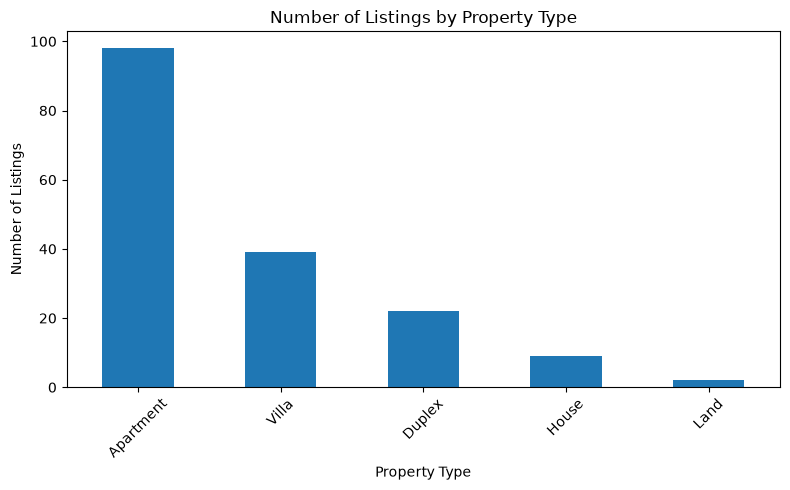

In [7]:
import matplotlib.pyplot as plt

df["property_type"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Listings by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
save_chart("Number of Listings by Property Type")

In [8]:
district_analysis = df.groupby("district").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).sort_values("avg_price", ascending=False).round(2)

district_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
district,,,,,
Sfax Centre,4,545038.00,533174.0,2515.68,211.25
Tunis Centre,7,449060.00,268757.0,1978.97,222.71
Mahdia,8,438702.00,349915.0,2302.25,173.00
Djerba,7,382478.57,306015.0,2282.14,162.14
Sousse Centre,11,381839.82,265446.0,1884.65,192.55
Bizerte,7,353831.29,354138.0,1893.05,168.43
Monastir,10,311163.80,231785.5,1882.54,150.90
La Marsa,11,260654.55,215071.0,1864.56,138.64
Nabeul,7,248952.71,171784.0,2038.80,127.29


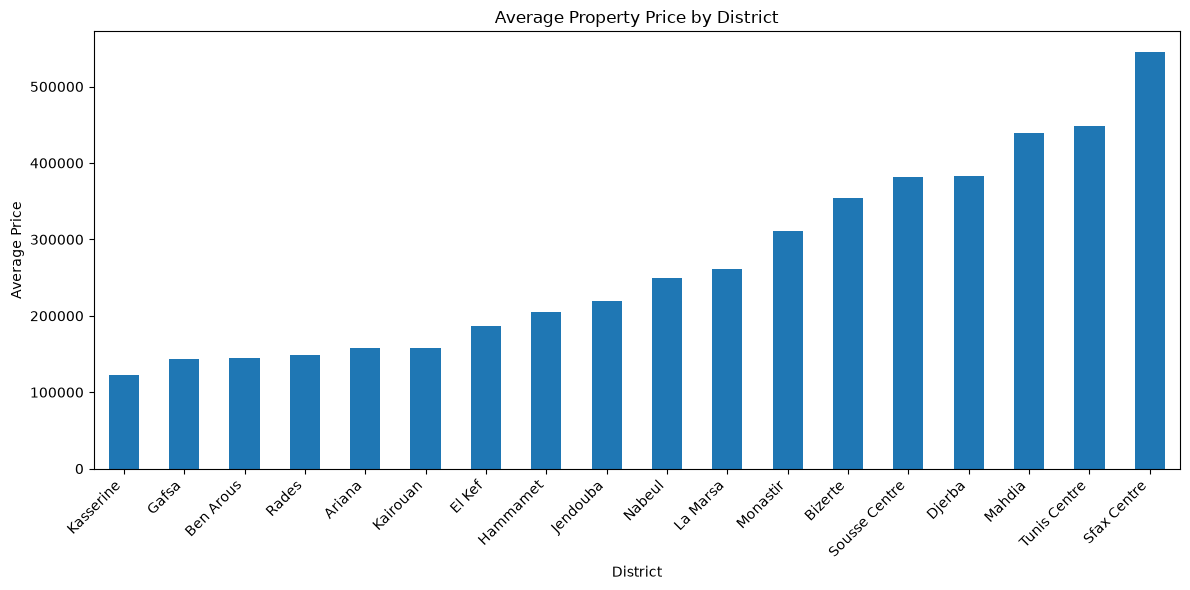

In [9]:
plt.figure(figsize=(12, 6))

district_analysis["avg_price"].sort_values().plot(
    kind="bar"
)

plt.title("Average Property Price by District")
plt.xlabel("District")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
save_chart("Average Property Price by District")

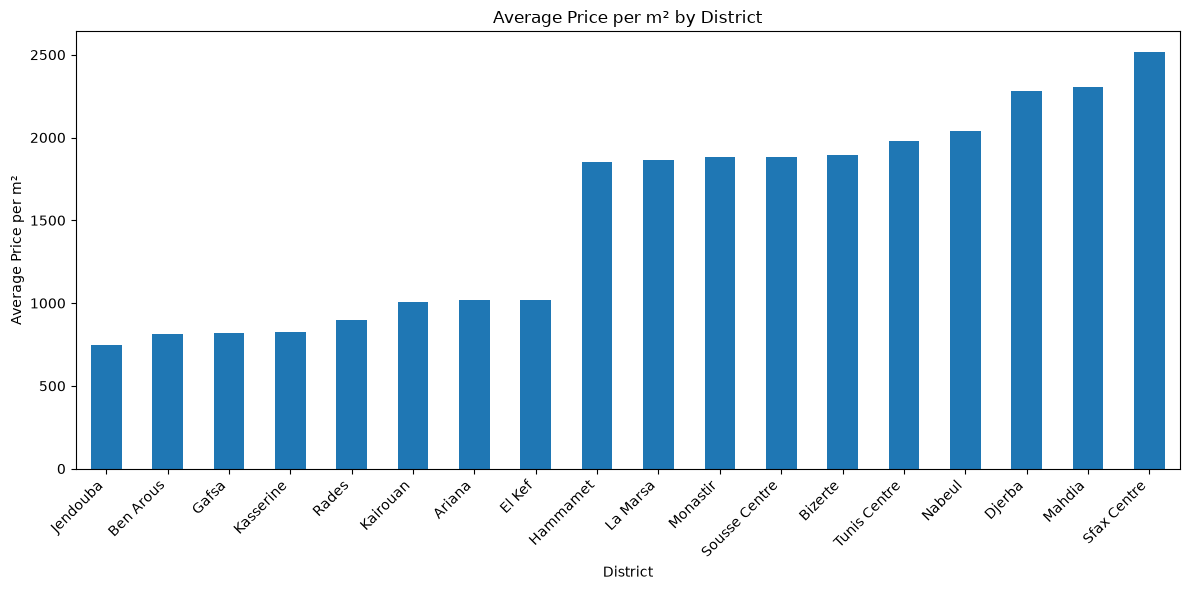

In [10]:
plt.figure(figsize=(12, 6))

district_analysis["avg_price_m2"].sort_values().plot(
    kind="bar"
)

plt.title("Average Price per m² by District")
plt.xlabel("District")
plt.ylabel("Average Price per m²")
plt.xticks(rotation=45, ha="right")
save_chart("Average Price per m² by District")

District Analysis Insight

District Analysis Insight:
Average price per square meter varies significantly across the districts in the dataset. Sfax Centre, Mahdia, and Djerba show the highest average prices per m², while Ben Arous, Gafsa, and Kasserine show lower values. These differences should be interpreted carefully because the number of listings varies between districts, and the results describe this dataset rather than the entire Tunisian real-estate market.

In [11]:
price_percentiles = df["price"].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

price_percentiles

0.25     95753.25
0.50    182574.00
0.75    303237.75
0.90    567504.90
0.95    768697.40
Name: price, dtype: float64

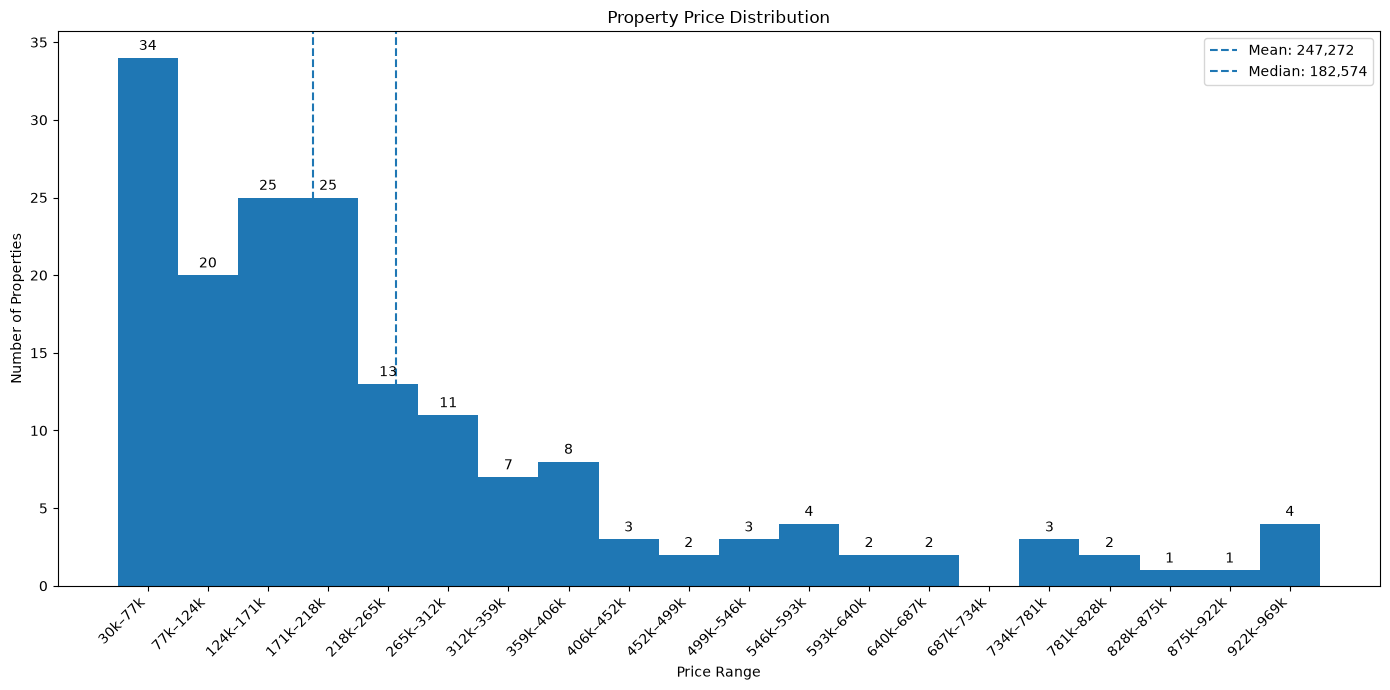

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Create histogram
counts, bins, patches = plt.hist(
    df["price"],
    bins=20
)

# Create labels for each price range
bin_labels = []

for i in range(len(bins) - 1):
    start = bins[i]
    end = bins[i + 1]

    label = f"{start/1000:.0f}k–{end/1000:.0f}k"
    bin_labels.append(label)

# Put price-range labels in the center of each bin
plt.xticks(
    [(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)],
    bin_labels,
    rotation=45,
    ha="right"
)

# Add number of properties above each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count + 0.5,
            f"{int(count)}",
            ha="center"
        )

# Add mean
plt.axvline(
    df["price"].mean(),
    linestyle="--",
    label=f"Mean: {df['price'].mean():,.0f}"
)

# Add median
plt.axvline(
    df["price"].median(),
    linestyle="--",
    label=f"Median: {df['price'].median():,.0f}"
)

plt.title("Property Price Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Properties")
plt.legend()

save_chart("Property Price Distribution")

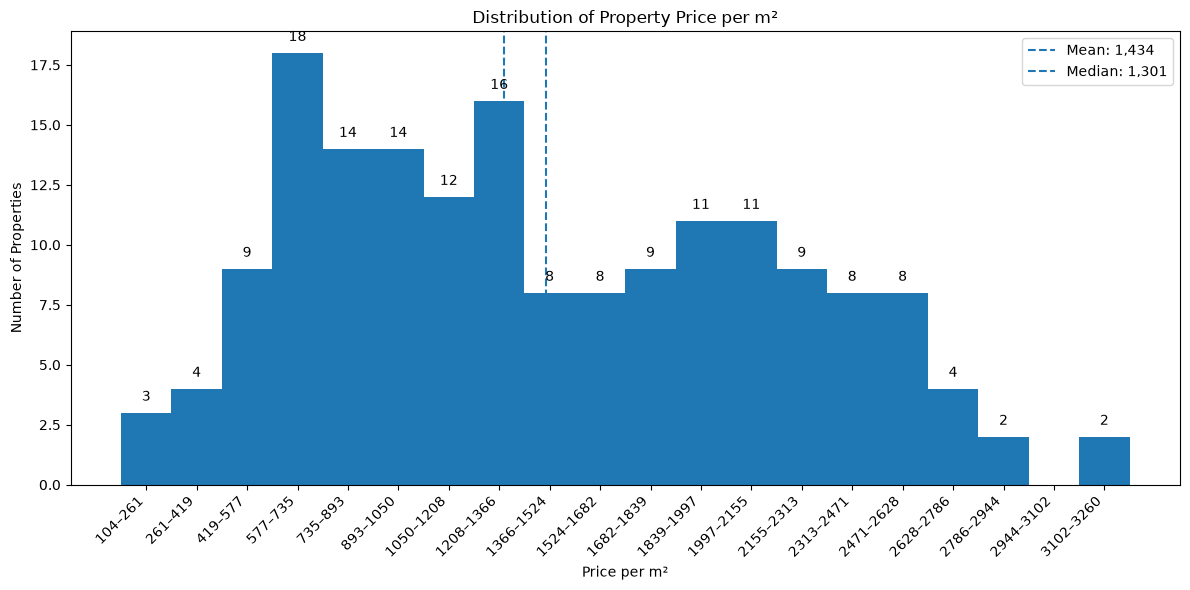

In [13]:
plt.figure(figsize=(12, 6))

counts, bins, patches = plt.hist(
    df["price_per_m2"],
    bins=20
)

# Add number of properties above each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count + 0.5,
            f"{int(count)}",
            ha="center"
        )

# Create price/m² range labels
bin_labels = []

for i in range(len(bins) - 1):
    start = bins[i]
    end = bins[i + 1]

    label = f"{start:.0f}–{end:.0f}"
    bin_labels.append(label)

plt.xticks(
    [(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)],
    bin_labels,
    rotation=45,
    ha="right"
)

# Mean
plt.axvline(
    df["price_per_m2"].mean(),
    linestyle="--",
    label=f"Mean: {df['price_per_m2'].mean():,.0f}"
)

# Median
plt.axvline(
    df["price_per_m2"].median(),
    linestyle="--",
    label=f"Median: {df['price_per_m2'].median():,.0f}"
)

plt.title("Distribution of Property Price per m²")
plt.xlabel("Price per m²")
plt.ylabel("Number of Properties")
plt.legend()

save_chart("price_per_m2_distribution")

Price per m² Distribution Insight:
The median price per m² is approximately 1,301, while the average is higher at 1,434. This difference suggests a right-skewed distribution, with a smaller number of properties having relatively high prices per m². Prices range from approximately 104 to 3,260 per m², indicating substantial variation across the listings.

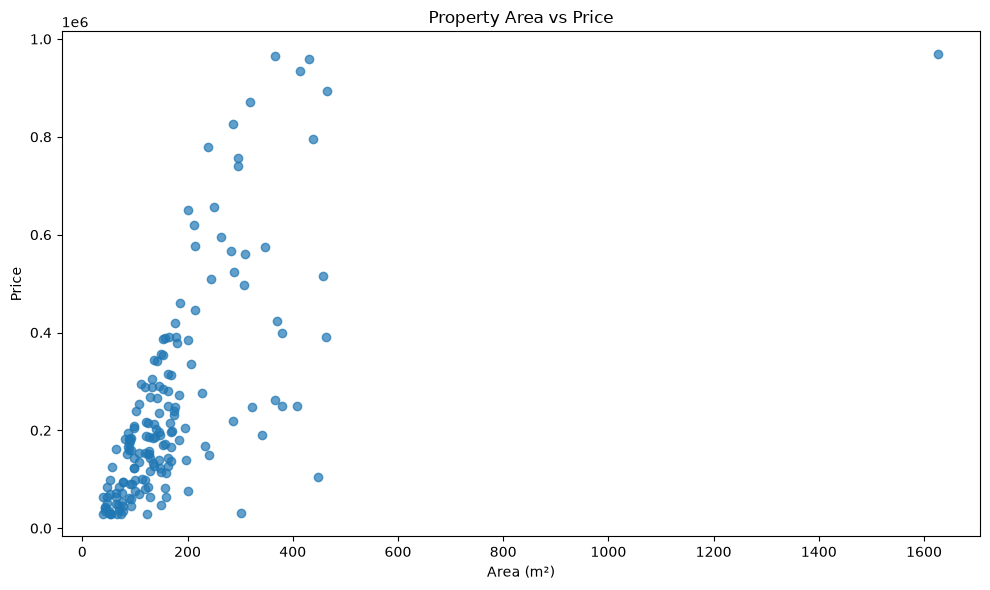

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["area"],
    df["price"],
    alpha=0.7
)

plt.title("Property Area vs Price")
plt.xlabel("Area (m²)")
plt.ylabel("Price")

save_chart("area_vs_price")

In [15]:
area_price_corr = df["area"].corr(df["price"])

print(f"Correlation between area and price: {area_price_corr:.2f}")

Correlation between area and price: 0.65


#Area vs Price Insight:

The correlation between property area and total price is 0.65, indicating a moderate-to-strong positive linear relationship in this dataset. Larger properties generally tend to have higher total prices. However, the relationship is not perfect, suggesting that other factors such as location, property type, condition, and price per m² also influence property prices.

In [16]:
bedroom_analysis = df.groupby("bedrooms").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean")
).round(2)

bedroom_analysis

,listings,avg_price,median_price,avg_price_m2
bedrooms,,,,
0,2,764253.00,764253.0,1203.44
1,36,147458.22,140807.0,1314.75
2,45,163424.84,151336.0,1395.86
3,48,262798.10,195968.0,1441.11
4,25,333359.12,249953.0,1542.83
5,9,512556.00,423474.0,1618.32
6,5,456761.20,460791.0,1786.85


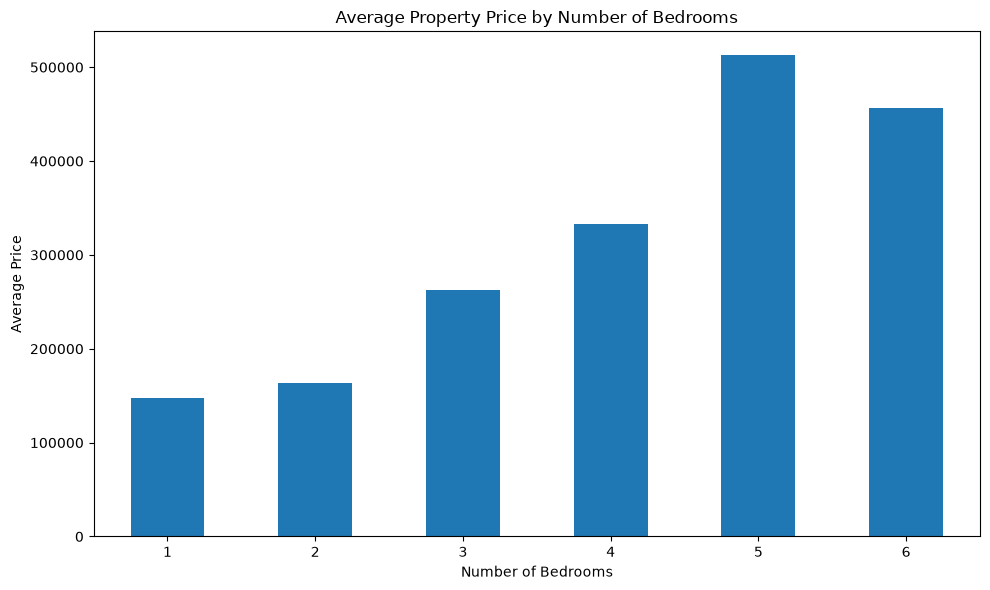

In [18]:
bedroom_analysis_residential = bedroom_analysis[
    bedroom_analysis.index > 0
]

plt.figure(figsize=(10, 6))

bedroom_analysis_residential["avg_price"].plot(kind="bar")

plt.title("Average Property Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

save_chart("average_price_by_bedrooms")

Bedroom Analysis Insight:

Property prices generally increase with the number of bedrooms in the dataset. Average prices rise from approximately 147,458 for one-bedroom properties to 512,556 for five-bedroom properties. Average price per m² also increases with bedroom count, from 1,315 to 1,618 between one and five bedrooms. The six-bedroom category shows a lower average price than five bedrooms, but it contains only five listings and should therefore be interpreted cautiously. Overall, bedroom count appears to be associated with property value, although other factors such as area, property type, location, and condition may also contribute.

In [19]:
condition_analysis = df.groupby("condition").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).sort_values("avg_price", ascending=False).round(2)

condition_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
condition,,,,,
Good,67,278796.66,197686.0,1516.43,176.27
New,16,256545.50,191827.5,1530.66,164.06
Excellent,57,222031.07,171784.0,1393.84,157.98
Fair,30,219878.07,125956.0,1275.16,190.43


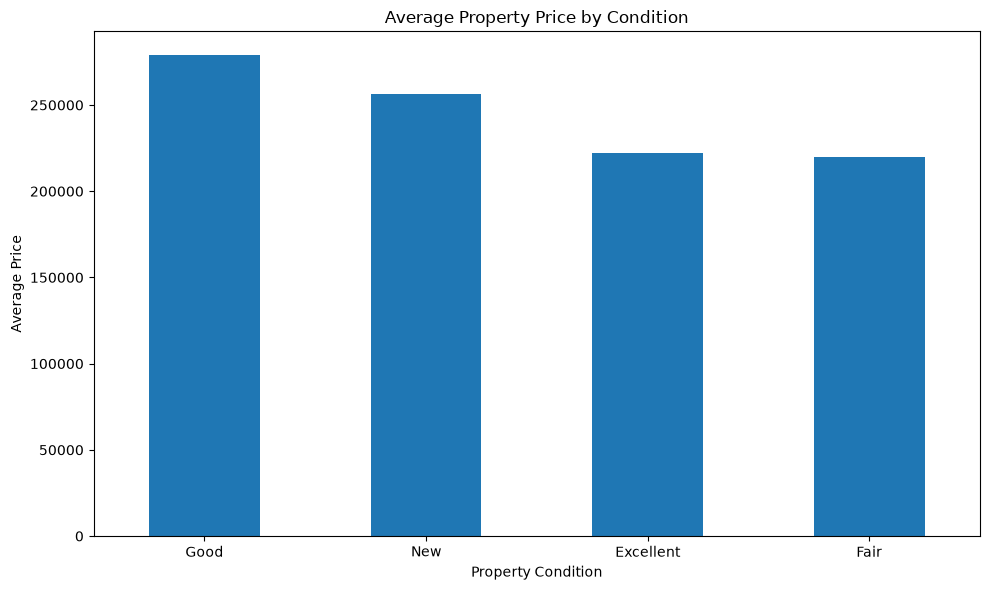

In [20]:
plt.figure(figsize=(10, 6))

condition_analysis["avg_price"].plot(kind="bar")

plt.title("Average Property Price by Condition")
plt.xlabel("Property Condition")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

save_chart("average_price_by_condition")

Condition Analysis Insight:

Properties classified as Good have the highest average total price at approximately 278,797, followed by New properties at 256,546. However, price per m² provides a clearer pattern: New and Good properties have the highest average prices per m², at approximately 1,531 and 1,516 respectively, while Fair properties have the lowest at 1,275. The results suggest that property condition may be associated with pricing, although differences in area, location, property type, and other characteristics may also influence these values.

The `condition` variable was randomly generated and is not directly linked to 
property price or other property characteristics. Therefore, differences in 
price across condition categories should not be interpreted as causal effects.

In [22]:
feature_analysis = df.groupby(["has_parking", "has_garden"]).agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).round(2).reset_index()

feature_analysis

,has_parking,has_garden,listings,avg_price,median_price,avg_price_m2,avg_area
0,False,False,38,256049.42,185780.0,1534.61,187.82
1,False,True,13,408089.46,290609.0,1636.86,241.31
2,True,False,93,158089.19,138494.0,1265.21,121.76
3,True,True,26,473033.88,485053.0,1789.82,290.58


Feature Analysis Insight:
   
    Properties with gardens have higher average prices and larger average areas than properties without gardens. However, these differences should not be interpreted as direct price effects. In the synthetic dataset, gardens are mainly associated with villas and houses, while parking was randomly assigned. Therefore, property type and size likely explain part of the observed differences.

In [23]:
parking_analysis = df.groupby("has_parking").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).round(2)

parking_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
has_parking,,,,,
False,51,294804.73,212257.0,1560.68,201.45
True,119,226900.64,167519.0,1379.84,158.65


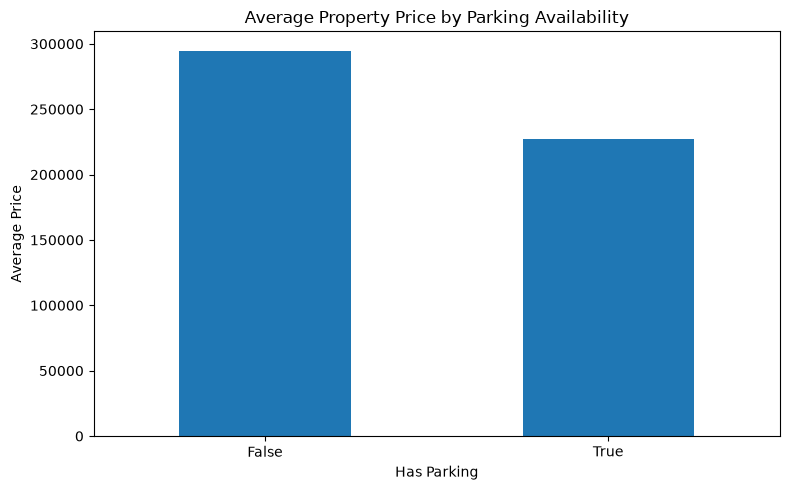

In [25]:
plt.figure(figsize=(8, 5))

parking_analysis["avg_price"].plot(kind="bar")

plt.title("Average Property Price by Parking Availability")
plt.xlabel("Has Parking")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

save_chart("average_price_by_parking")

In [24]:
garden_analysis = df.groupby("has_garden").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).round(2)

garden_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
has_garden,,,,,
False,131,186505.14,152448.0,1343.36,140.92
True,39,451385.74,390989.0,1738.84,274.15


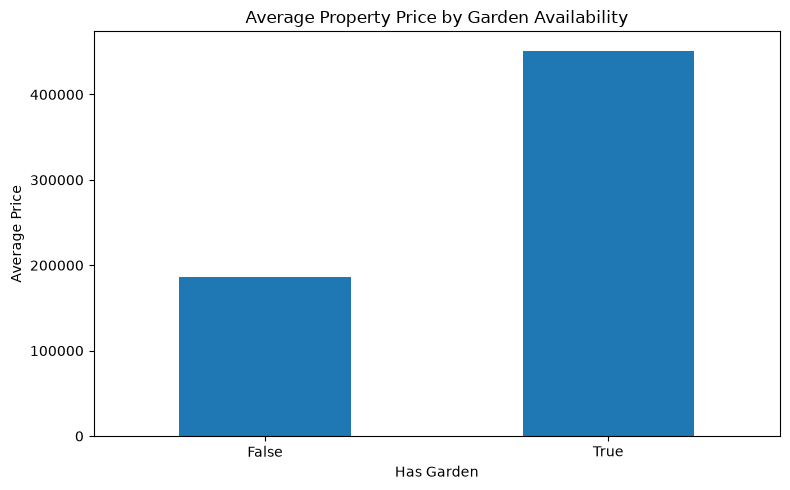

In [26]:
plt.figure(figsize=(8, 5))

garden_analysis["avg_price"].plot(kind="bar")

plt.title("Average Property Price by Garden Availability")
plt.xlabel("Has Garden")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

save_chart("average_price_by_garden")

In [27]:
price_category_analysis = df.groupby("price_category").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean")
).round(2)

price_category_analysis

,listings,avg_price,median_price,avg_price_m2
price_category,,,,
Budget,32,47921.28,46618.5,721.61
Luxury,35,338587.34,334806.0,1920.23
Premium,47,191801.55,186236.0,1492.07
Standard,34,111582.38,113907.5,991.78
Ultra-Luxury,22,720168.41,698479.5,2256.70


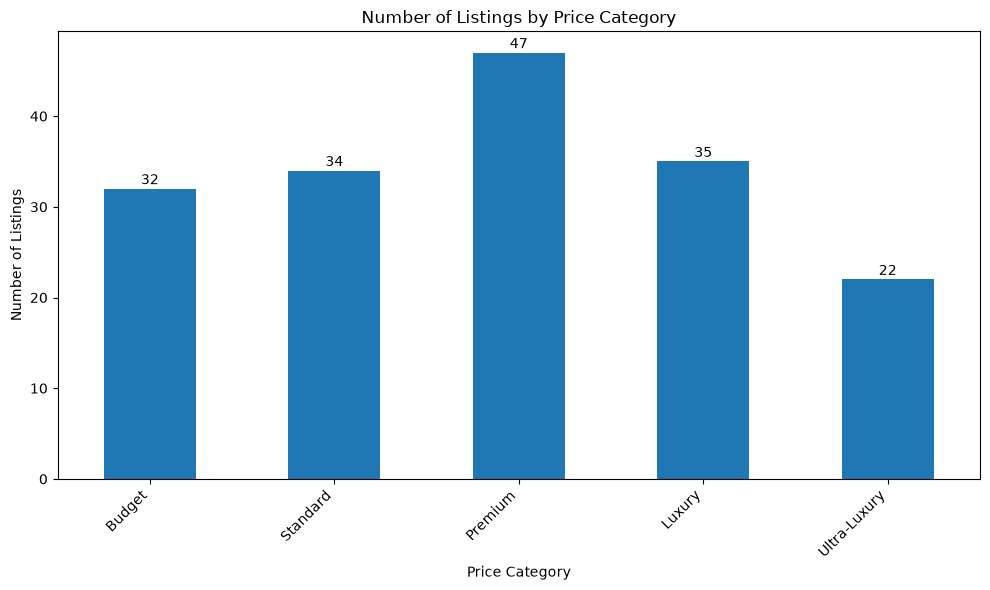

In [28]:
plt.figure(figsize=(10, 6))

price_category_counts = df["price_category"].value_counts()

# Put categories in logical order
category_order = [
    "Budget",
    "Standard",
    "Premium",
    "Luxury",
    "Ultra-Luxury"
]

price_category_counts = price_category_counts.reindex(category_order)

price_category_counts.plot(kind="bar")

plt.title("Number of Listings by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")

for i, count in enumerate(price_category_counts):
    plt.text(
        i,
        count + 0.5,
        str(count),
        ha="center"
    )

save_chart("listings_by_price_category")

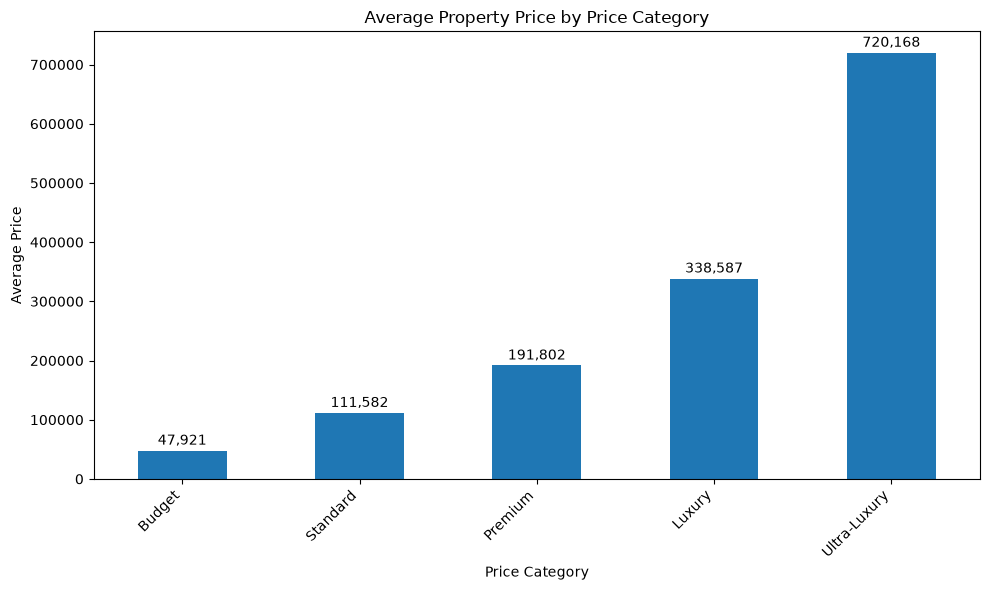

In [29]:
plt.figure(figsize=(10, 6))

price_category_analysis["avg_price"].reindex([
    "Budget",
    "Standard",
    "Premium",
    "Luxury",
    "Ultra-Luxury"
]).plot(kind="bar")

plt.title("Average Property Price by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(
    price_category_analysis["avg_price"].reindex([
        "Budget",
        "Standard",
        "Premium",
        "Luxury",
        "Ultra-Luxury"
    ])
):
    plt.text(
        i,
        value + 10000,
        f"{value:,.0f}",
        ha="center"
    )

save_chart("average_price_by_price_category")

In [30]:
market_analysis = df.groupby("market_type").agg(
    listings=("id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_price_m2=("price_per_m2", "mean"),
    avg_area=("area", "mean")
).sort_values("avg_price", ascending=False).round(2)

market_analysis

,listings,avg_price,median_price,avg_price_m2,avg_area
market_type,,,,,
Urban,22,432900.45,289254.5,2029.39,205.55
Coastal,61,305627.51,215071.0,1994.13,144.62
Rural,87,159415.28,127156.0,890.88,181.71


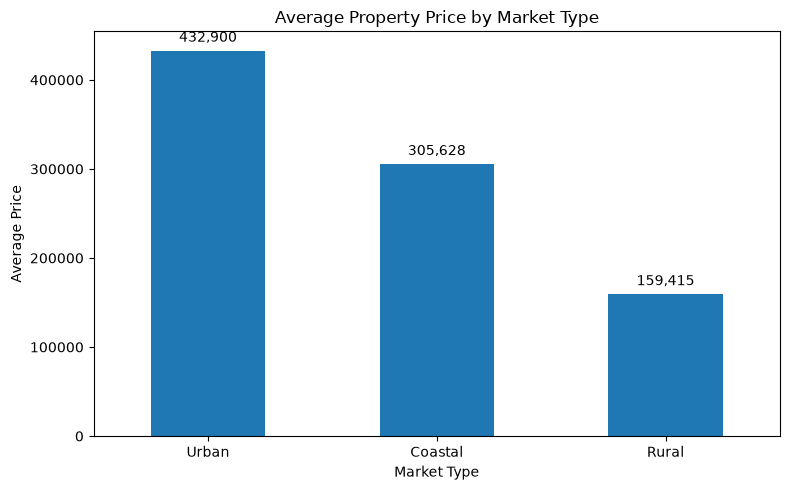

In [31]:
plt.figure(figsize=(8, 5))

market_analysis["avg_price"].plot(kind="bar")

plt.title("Average Property Price by Market Type")
plt.xlabel("Market Type")
plt.ylabel("Average Price")
plt.xticks(rotation=0)

for i, value in enumerate(market_analysis["avg_price"]):
    plt.text(
        i,
        value + 10000,
        f"{value:,.0f}",
        ha="center"
    )

save_chart("average_price_by_market_type")

Market Type Insight: 

Urban properties have the highest average price and price per m² in the dataset, followed by coastal properties, while rural properties show substantially lower values. Urban listings also have the largest average area. However, these differences should be interpreted as patterns within the synthetic dataset rather than conclusions about the Tunisian real-estate market.

In [32]:
listing_duration_stats = df["days_listed"].describe().round(2)

listing_duration_stats

count    170.00
mean      25.47
std       22.66
min        7.00
25%       10.00
50%       16.50
75%       31.50
max       96.00
Name: days_listed, dtype: float64

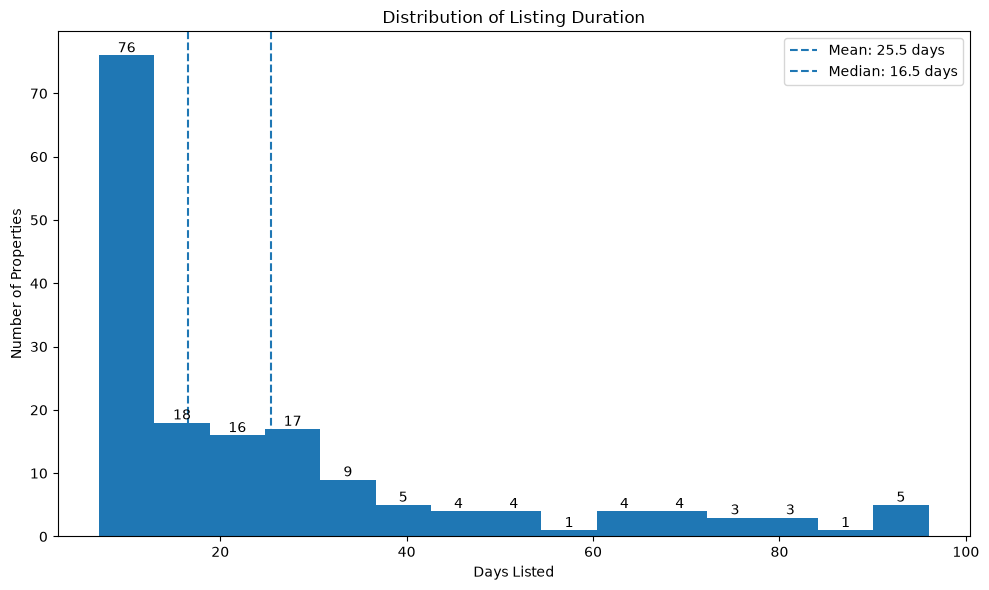

In [33]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    df["days_listed"],
    bins=15
)

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count + 0.5,
            f"{int(count)}",
            ha="center"
        )

plt.axvline(
    df["days_listed"].mean(),
    linestyle="--",
    label=f"Mean: {df['days_listed'].mean():.1f} days"
)

plt.axvline(
    df["days_listed"].median(),
    linestyle="--",
    label=f"Median: {df['days_listed'].median():.1f} days"
)

plt.title("Distribution of Listing Duration")
plt.xlabel("Days Listed")
plt.ylabel("Number of Properties")
plt.legend()

save_chart("listing_duration_distribution")

In [34]:
value_score_stats = df["value_score"].describe().round(2)

value_score_stats

count    170.00
mean      50.46
std       28.53
min        0.00
25%       27.00
50%       50.50
75%       75.50
max       99.00
Name: value_score, dtype: float64

In [35]:
high_value = df[df["value_score"] >= 75]

print(f"Properties with value score >= 75: {len(high_value)}")
print(f"Percentage: {len(high_value) / len(df) * 100:.1f}%")

Properties with value score >= 75: 43
Percentage: 25.3%


Value Score Insight:

 The value score has a median of 50.5 and ranges from 0 to 99. A total of 43 properties, representing 25.3% of the dataset, have a value score of at least 75. These properties can be considered high-value candidates for further analysis, although the score reflects the methodology used to construct the synthetic dataset.

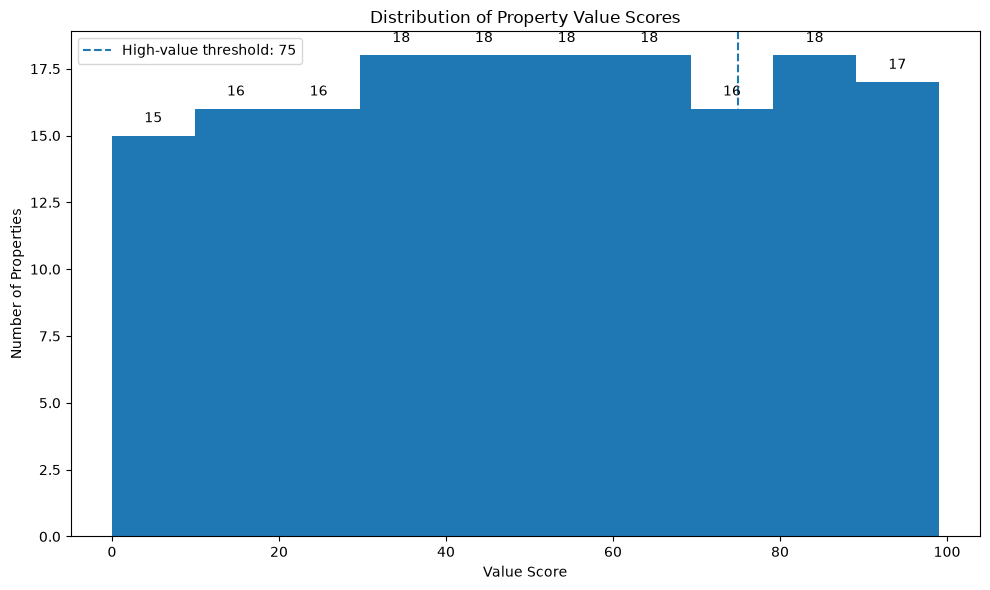

In [38]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    df["value_score"],
    bins=10
)

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count + 0.5,
            f"{int(count)}",
            ha="center"
        )

plt.axvline(
    75,
    linestyle="--",
    label="High-value threshold: 75"
)

plt.title("Distribution of Property Value Scores")
plt.xlabel("Value Score")
plt.ylabel("Number of Properties")
plt.legend()

save_chart("value_score_distribution")

In [41]:
reasonable_price = df["price"].median()

investment_opportunities = df[
    (df["value_score"] >= 75) &
    (df["days_listed"] <= 30) &
    (df["property_type"] != "Land") &
    (df["price"] <= reasonable_price)
].copy()

investment_opportunities = investment_opportunities.sort_values(
    "value_score",
    ascending=False
)

investment_opportunities[
    [
        "id",
        "title",
        "property_type",
        "location",
        "price",
        "price_per_m2",
        "area",
        "bedrooms",
        "days_listed",
        "value_score"
    ]
]

,id,title,property_type,location,price,price_per_m2,area,bedrooms,days_listed,value_score
164,195,Apartment 2P 123m² - Ben Arous,Apartment,Ben Arous - Tunisia,30000,243.90,123,2,27,99.0
114,136,Apartment 3P 150m² - Kasserine,Apartment,Kasserine - Tunisia,47350,315.67,150,3,8,98.0
45,59,Apartment 1P 73m² - Kasserine,Apartment,Kasserine - Tunisia,30000,410.96,73,1,12,96.0
59,76,Villa 4P 448m² - Ben Arous,Villa,Ben Arous - Tunisia,104074,232.31,448,4,18,96.0
84,103,Duplex 3P 200m² - Jendouba,Duplex,Jendouba - Tunisia,75961,379.80,200,3,9,95.0
47,62,Apartment 2P 78m² - Rades,Apartment,Rades - Tunisia,35881,460.01,78,2,10,95.0
125,152,Apartment 1P 128m² - Ben Arous,Apartment,Ben Arous - Tunisia,63134,493.23,128,1,8,93.0
123,150,Apartment 3P 157m² - Ben Arous,Apartment,Ben Arous - Tunisia,81195,517.17,157,3,8,92.0
3,6,Duplex 3P 93m² - Gafsa,Duplex,Gafsa - Tunisia,45887,493.41,93,3,20,91.0
100,121,Apartment 2P 54m² - Ariana,Apartment,Ariana - Tunisia,30000,555.56,54,2,12,90.0


In [44]:
investment_opportunities.to_csv(
    "../data/eda_investment_opportunities.csv",
    index=False
)

In [45]:
correlation_columns = [
    "price",
    "price_per_m2",
    "area",
    "bedrooms",
    "days_listed",
    "quality_score",
    "features_score",
    "value_score"
]

correlation_matrix = df[correlation_columns].corr().round(2)

correlation_matrix

,price,price_per_m2,area,bedrooms,days_listed,quality_score,features_score,value_score
price,1.00,0.65,0.65,0.37,-0.04,-0.01,0.25,-0.44
price_per_m2,0.65,1.00,0.01,0.15,-0.11,0.05,0.07,-0.93
area,0.65,0.01,1.00,0.23,0.00,-0.07,0.16,0.13
bedrooms,0.37,0.15,0.23,1.00,0.04,0.08,0.37,0.04
days_listed,-0.04,-0.11,0.00,0.04,1.00,0.02,-0.11,0.13
quality_score,-0.01,0.05,-0.07,0.08,0.02,1.00,0.06,-0.06
features_score,0.25,0.07,0.16,0.37,-0.11,0.06,1.00,0.11
value_score,-0.44,-0.93,0.13,0.04,0.13,-0.06,0.11,1.00


Correlation Analysis Insight:

 Property price shows a moderate positive correlation with area (0.65) and a weaker positive correlation with bedrooms (0.37). Value score has a strong negative correlation with price per m² (-0.93), reflecting the way the score is constructed rather than an independent market relationship. Listing duration and quality score show weak correlations with most numeric variables. Since the dataset is synthetic and some variables are programmatically generated, correlations should be interpreted as exploratory patterns rather than causal relationships.

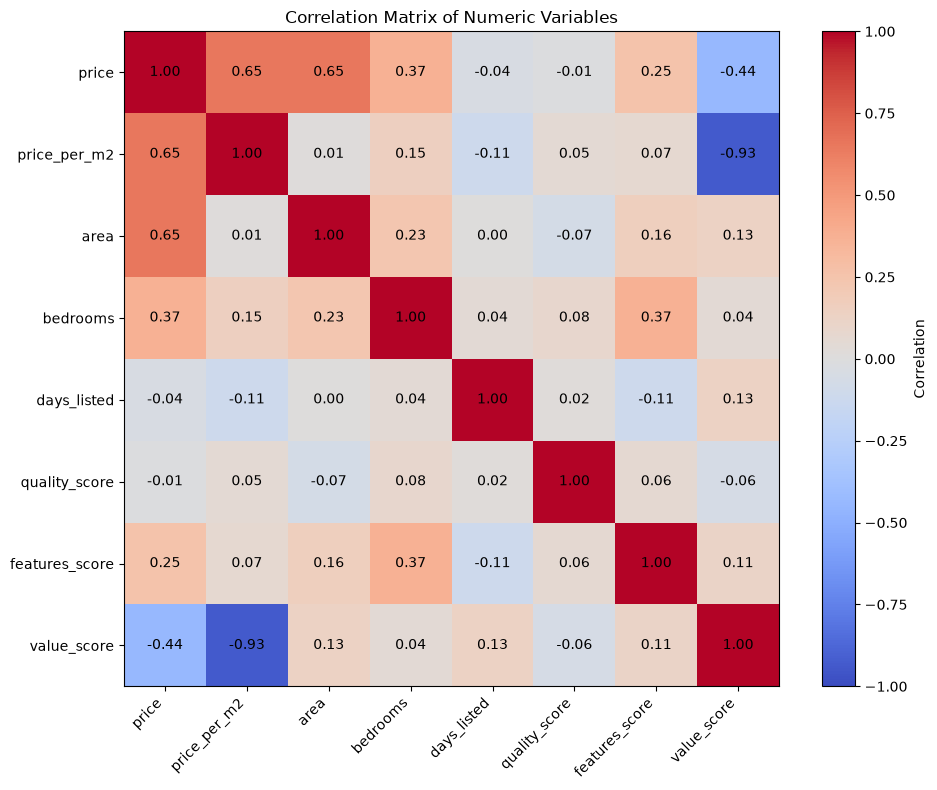

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numeric Variables")

save_chart("correlation_matrix")